Data Analysis Python Project- GoPuff Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/ItsFaizan-official/Gopuff-market-analysis/refs/heads/main/gopuff_data.csv")

In [ ]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [ ]:
df.tail(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


Size of data

In [ ]:
print("Size of Data:" , df.shape)

Size of Data: (8523, 12)


Field Information

In [ ]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [ ]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [ ]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


Data Cleaning

In [ ]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [ ]:
df['Item Fat Content']=df['Item Fat Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [ ]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


Business Requirements

KPI's Requirements

In [ ]:
#total sales
total_sales=df['Sales'].sum()
print("Total Sales:", total_sales)


Total Sales: 1201681.4808


In [ ]:
#averge sales
avg_sales=df['Sales'].mean
print("Average Sales:",avg_sales)

Average Sales: <bound method Series.mean of 0       145.4786
1       115.3492
2       165.0210
3       126.5046
4        55.1614
          ...   
8518    164.5526
8519    241.6828
8520     86.6198
8521     97.8752
8522    112.2544
Name: Sales, Length: 8523, dtype: float64>


In [ ]:
# Number of Items Sold (no Quantity column, so fallback = count of rows)
no_of_items_sold = df['Sales'].count()
print("Number oF Items Sold:",no_of_items_sold)

Number oF Items Sold: 8523


In [ ]:
#Avearge Ratings
avg_ratings=df['Rating'].mean()
print("Average Ratings:",avg_ratings)

Average Ratings: 3.965857092573038


CHART CONTENTS

TOTAL SALES BY FAT CONTENT

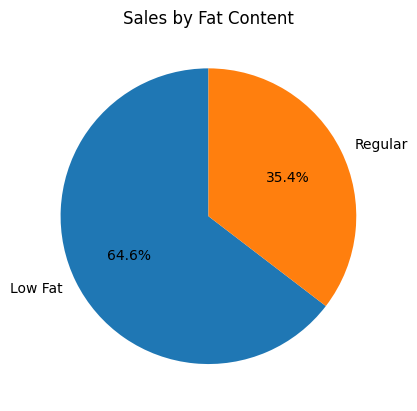

In [78]:
import matplotlib.pyplot as plt
sales_by_fat=df.groupby('Item Fat Content')['Sales'].sum()
#making plot
plt.pie(
    sales_by_fat,
    labels=sales_by_fat.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Sales by Fat Content')
plt.show()

Total Sales by Item Type

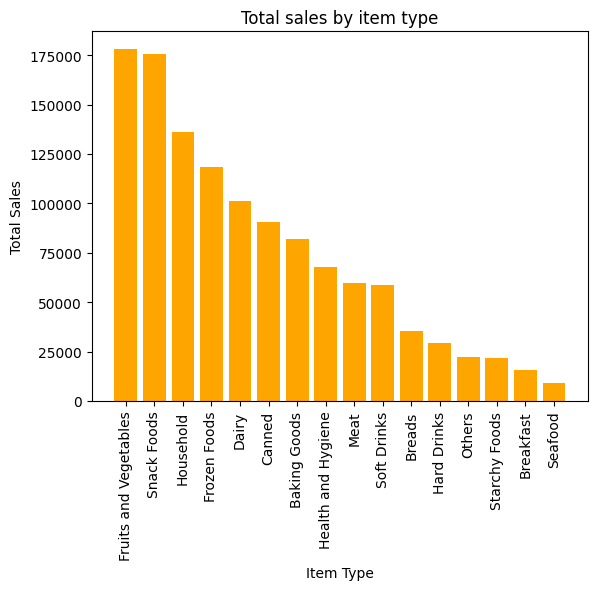

In [86]:
#group and sort sales by item type
sales_by_type=df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
#create bar chart
plt.bar(sales_by_type.index,sales_by_type.values,color='orange')
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total sales by item type')
plt.xticks(rotation=90)
plt.show()

Fat content by outlet for total sales

<Axes: title={'center': 'outlet tier by item fat content'}, xlabel='outlier tier', ylabel='total sales'>

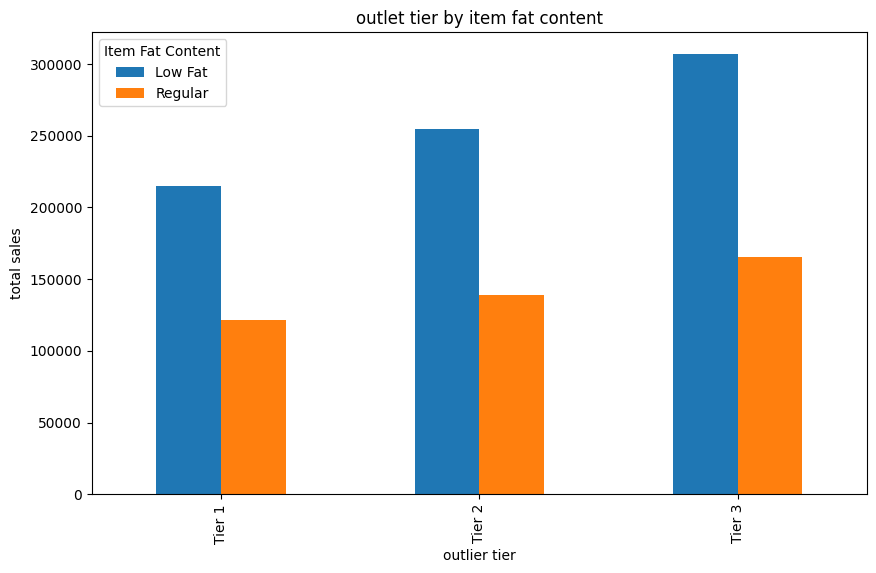

In [89]:
Rishi=df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
Rishi.plot(kind='bar',
           figsize=(10,6),
           title='outlet tier by item fat content',
           xlabel='outlier tier',
           ylabel='total sales'
           )

Total Sales By Outlet Establishmant


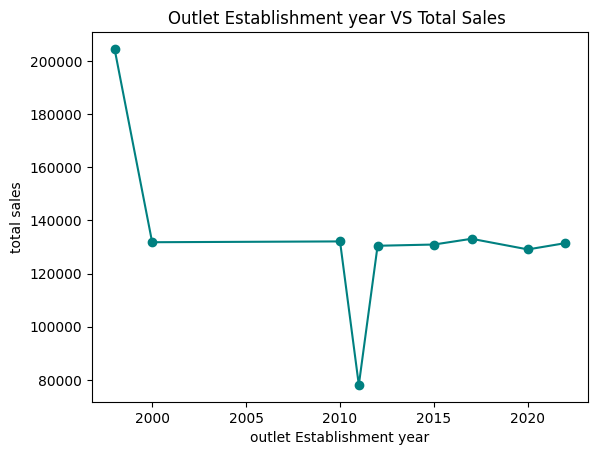

<Figure size 700x400 with 0 Axes>

In [106]:
#line chart
sales_by_year=df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-', color='teal')
plt.xlabel('outlet Establishment year')
plt.ylabel('total sales')
plt.title('Outlet Establishment year VS Total Sales ')
plt.figure(figsize=(7, 4))
plt.show()

Sales by Outlet Size

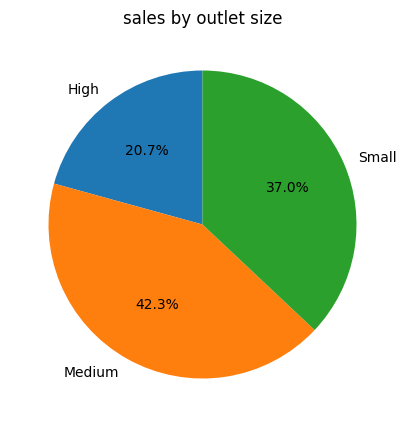

In [114]:
#pie chart :total sales by outlet size
Rishi=df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(5,5))
plt.pie(
    Rishi,
    labels=Rishi.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('sales by outlet size')
plt.show()

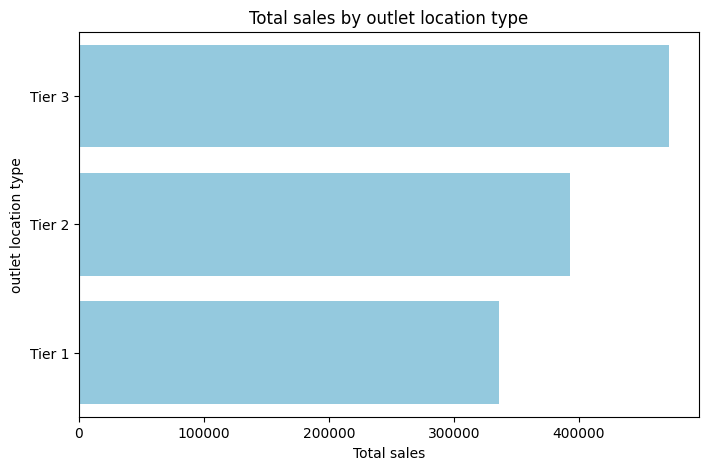

In [124]:
sales_by_location=df.groupby('Outlet Location Type')['Sales'].sum().reset_index().sort_values('Sales',ascending=False)
plt.figure(figsize=(8,5))
#create horizontal bar chart
ax=sns.barplot(
    x='Sales',
    y='Outlet Location Type',
    data=sales_by_location,
    color='skyblue'
)
plt.xlabel('Total sales')
plt.ylabel('outlet location type')
plt.title('Total sales by outlet location type')
plt.show()